In [1]:
import os, re
import numpy as np
import scanpy as sc
from os.path import join
import pandas as pd

import sys
import scipy.io as sio
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spamosaic.framework import SpaMosaic
import spamosaic.utils as utls
from spamosaic.preprocessing import RNA_preprocess, ADT_preprocess, Epigenome_preprocess, harmony

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 

In [2]:
data_dir = '../../../data/processed/Lymph-S1-S2-S2'
ad_mult_rna = sc.read_h5ad(join(data_dir, 'S1/ad_rna.h5ad'))
ad_mult_adt = sc.read_h5ad(join(data_dir, 'S1/ad_adt.h5ad'))
ad_test_rna = sc.read_h5ad(join(data_dir, 'S2-rna/ad_rna.h5ad'))
ad_test_adt = sc.read_h5ad(join(data_dir, 'S2-adt/ad_adt.h5ad'))

input_dict = { 
    'rna':  [ad_mult_rna,  ad_test_rna,  None],
    'adt':  [ad_mult_adt,  None       ,  ad_test_adt],
}

input_key = 'dimred_bc'
batch_key = 'src'

In [3]:
RNA_preprocess(input_dict['rna'], batch_corr=True, n_hvg=10000, batch_key=batch_key, key=input_key)
ADT_preprocess(input_dict['adt'], batch_corr=True, batch_key=batch_key, key=input_key)

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
Reach convergence after 3 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
Reach convergence after 4 iteration(s).


In [4]:
cm_ratio = 0.5 
model = SpaMosaic(
    modBatch_dict=input_dict, input_key=input_key,
    batch_key=batch_key, 
    intra_knns=10, inter_knn_base=10, 
    w_g=0.8,
    seed=1234, 
    device='cuda:0'
)

model.train(net='wlgcn', lr=0.01, T=0.01, n_epochs=100)

batch0: ['rna', 'adt']
batch1: ['rna']
batch2: ['adt']
------Calculating spatial graph...
The graph contains 34840 edges, 3484 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 33590 edges, 3359 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 34840 edges, 3484 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 33590 edges, 3359 cells.
10.0000 neighbors per cell on average.
Searching MNN within rna
Finding MNN between (s1, s2-rna) using KNN (10, 10)
Number of mnn pairs for rna:5319
Searching MNN within adt
Finding MNN between (s1, s2-adt) using KNN (10, 10)
Number of mnn pairs for adt:13523


100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.19it/s]


In [5]:
ad_embs = model.infer_emb(input_dict, emb_key='emb', final_latent_key='merged_emb')
ad_mosaic = sc.concat(ad_embs)
ad_mosaic = utls.get_umap(ad_mosaic, use_reps=['merged_emb'])

/home/yanxh/anaconda3/envs/spamosaic-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


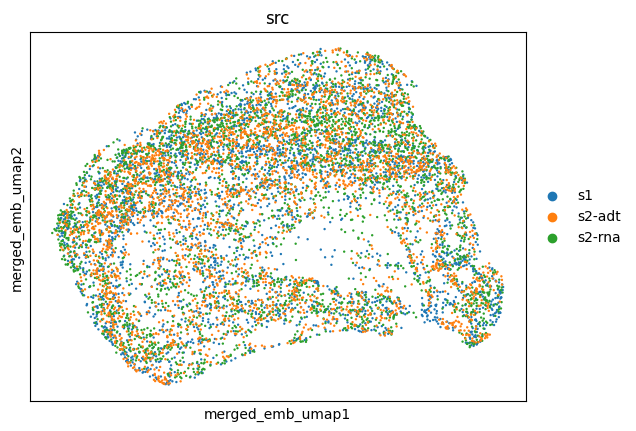

In [6]:
utls.plot_basis(ad_mosaic, 'merged_emb_umap', [batch_key])

In [7]:
fig_dir = f'../../../results/embeddings/SpaMosaic/Lymph-S1-S2-S2'
os.makedirs(fig_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['merged_emb'], index=ad_mosaic.obs_names)
df.to_csv(join(fig_dir, 'df_emb.csv'))